In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Visadataset.csv')

In [3]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [4]:
df.drop('case_id',inplace=True,axis=1)

In [5]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [7]:
from datetime import date

In [14]:
todays_date=date.today()
current_year=todays_date.year

In [15]:

current_year

2026

In [16]:
df['company_age']=current_year-df["yr_of_estab"]

In [18]:
df.drop('yr_of_estab',axis=1,inplace=True)

In [19]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,Certified,21


In [20]:
X=df.drop('case_status',axis=1)
y=df.case_status

In [23]:
y=y.map({'Denied': 0, 'Certified': 1})

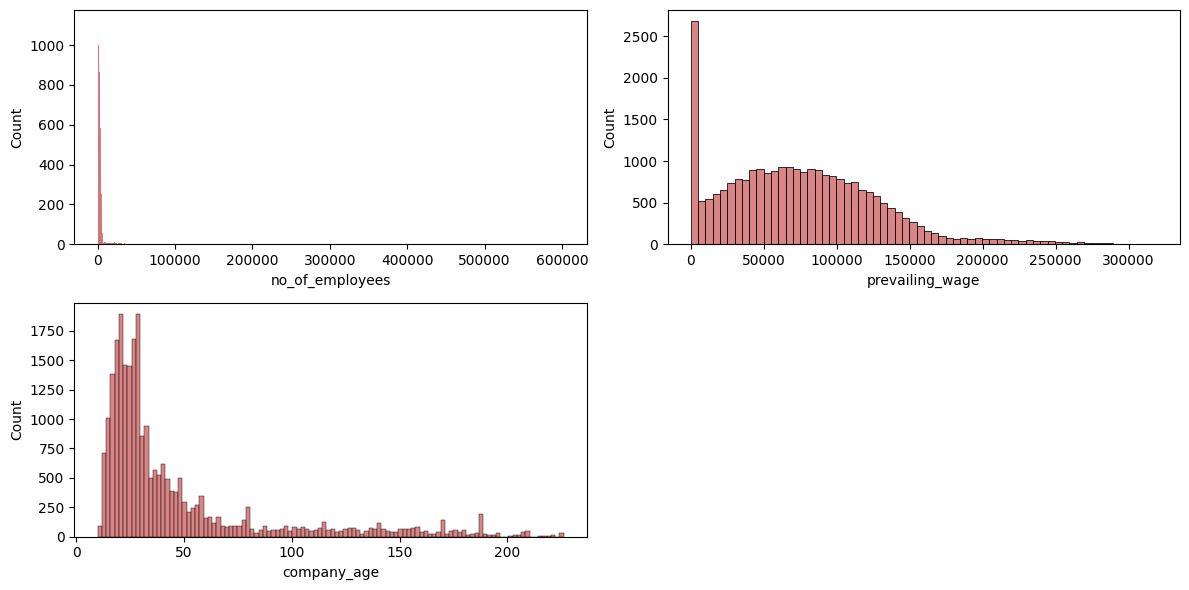

In [25]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(['no_of_employees','prevailing_wage','company_age']):
    plt.subplot(2, 2, i+1)
    sns.histplot(x=X[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

In [28]:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
continuous_features=[feature for feature in num_features if feature not in discrete_features]

In [29]:
X[continuous_features].skew(axis=0, skipna=True)

no_of_employees    12.265260
prevailing_wage     0.755776
company_age         2.037301
dtype: float64

In [30]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
transform_features = ['company_age', 'no_of_employees']
X_copy=pt.fit_transform(X[transform_features])

In [32]:

X_copy = pd.DataFrame(X_copy, columns=transform_features)

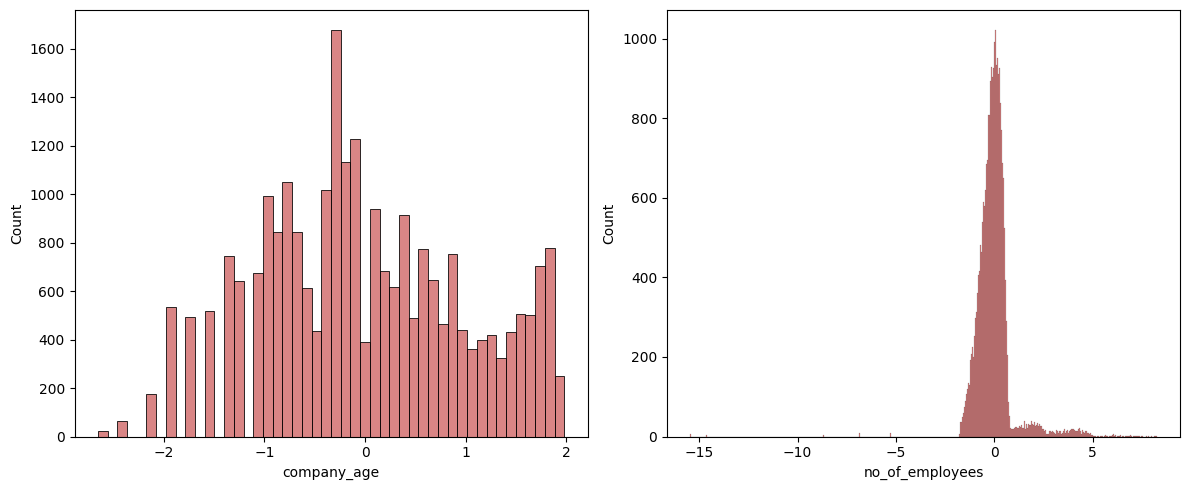

In [33]:
plt.figure(figsize=(12, 5))
for i, col in enumerate(transform_features):
    plt.subplot(1, 2, i+1)
    sns.histplot(x=X_copy[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

In [35]:
or_columns = ['has_job_experience','requires_job_training','full_time_position','education_of_employee']
oh_columns = ['continent','unit_of_wage','region_of_employment']
transform_columns= ['no_of_employees','company_age']

from sklearn.preprocessing import OneHotEncoder, StandardScaler,OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline

oh_encoder=OneHotEncoder()
or_encoder=OrdinalEncoder()
numeric_transformer=StandardScaler()

transform_pipe=Pipeline(
    steps=[('transformer',PowerTransformer(method='yeo-johnson'))]
    
)
preprocessor=ColumnTransformer([
    ('OneHotEncoding',oh_encoder,oh_columns),
    ('OrdinalEncoding',or_encoder,or_columns),
    ('Power Transformation',transform_pipe,transform_columns),
    ('Standard  Scaling',numeric_transformer,num_features)
])

In [36]:
X=preprocessor.fit_transform(X)

In [37]:
X

array([[ 0.        ,  1.        ,  0.        , ...,  0.38666657,
        -1.39853722, -0.65122993],
       [ 0.        ,  1.        ,  0.        , ..., -0.14228155,
         0.1698353 , -0.53321103],
       [ 0.        ,  1.        ,  0.        , ...,  1.69498375,
         0.91907852, -0.6748337 ],
       ...,
       [ 0.        ,  1.        ,  0.        , ..., -0.19871259,
         1.36027953,  1.63833662],
       [ 0.        ,  1.        ,  0.        , ..., -0.16387483,
         0.22150859,  2.18122353],
       [ 0.        ,  1.        ,  0.        , ..., -0.10805575,
        -0.06776315,  0.45814768]])

In [38]:
from imblearn.combine import SMOTEENN
smt = SMOTEENN(random_state=42,sampling_strategy='minority')
X_res,y_res=smt.fit_resample(X,y)

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
X_train.shape,X_test.shape

((13644, 24), (3412, 24))

In [40]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [41]:
def evaluate_clf(true,pred):
    acc=accuracy_score(true,pred)
    precision=precision_score(true,pred)
    rec=recall_score(true,pred)
    f1=f1_score(true,pred)
    roc_auc=roc_auc_score(true,pred)
   
    return acc,precision,rec,f1,roc_auc

In [42]:
models={
    'RandomForest':RandomForestClassifier(),
    'AdaboostClassifier':AdaBoostClassifier(),
    'GradientBoosting':GradientBoostingClassifier(),
    'LogisticRegression':LogisticRegression(),
    'KNeighboursClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'Support Vector classifier':SVC(),
    'XGBoostClassifier':XGBClassifier(),
    'CatBoostClassifier':CatBoostClassifier()
}

In [43]:
def evaluate_models(X,y,models):
    models_list=[]
    accuracy_list=[]
    auc=[]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    for i in range(len(list(models))):
        model=list(models.values())[i]
        model.fit(X_train,y_train)
        y_train_pred=model.predict(X_train)
        y_test_pred=model.predict(X_test)
        
        model_train_accuracy, model_train_f1,model_train_precision,model_train_recall,model_train_rocauc_score=evaluate_clf(y_train ,y_train_pred)
        model_test_accuracy,model_test_f1,model_test_precision,model_test_recall,model_test_rocauc_score=evaluate_clf(y_test, y_test_pred)
        
        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print('Model performance for Training set')
        print("- Accuracy: {:.4f}".format(model_train_accuracy))
        print('- F1 score: {:.4f}'.format(model_train_f1)) 
        print('- Precision: {:.4f}'.format(model_train_precision))
        print('- Recall: {:.4f}'.format(model_train_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

        print('----------------------------------')

        print('Model performance for Test set')
        print('- Accuracy: {:.4f}'.format(model_test_accuracy))
        accuracy_list.append(model_test_accuracy)
        print('- F1 score: {:.4f}'.format(model_test_f1))
        print('- Precision: {:.4f}'.format(model_test_precision))
        print('- Recall: {:.4f}'.format(model_test_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
        auc.append(model_test_rocauc_score)
        print('='*35)
        print('\n')
        
    report=pd.DataFrame(list(zip(models_list, accuracy_list)), columns=['Model Name', 'Accuracy']).sort_values(by=['Accuracy'], ascending=False)
        
    return report
        
        

In [44]:
base_model_report=evaluate_models(X_res,y_res,models)

RandomForest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9417
- F1 score: 0.9412
- Precision: 0.9297
- Recall: 0.9354
- Roc Auc Score: 0.9407


AdaboostClassifier
Model performance for Training set
- Accuracy: 0.8580
- F1 score: 0.8395
- Precision: 0.8559
- Recall: 0.8477
- Roc Auc Score: 0.8579
----------------------------------
Model performance for Test set
- Accuracy: 0.8511
- F1 score: 0.8224
- Precision: 0.8574
- Recall: 0.8395
- Roc Auc Score: 0.8516


GradientBoosting
Model performance for Training set
- Accuracy: 0.8878
- F1 score: 0.8726
- Precision: 0.8863
- Recall: 0.8794
- Roc Auc Score: 0.8877
----------------------------------
Model performance for Test set
- Accuracy: 0.8751
- F1 score: 0.8530
- Precision: 0.8761
- Recall: 0.8644
- Roc Auc Score: 0.8752




e:\Miniconda3\envs\visa\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression
Model performance for Training set
- Accuracy: 0.7366
- F1 score: 0.7076
- Precision: 0.7314
- Recall: 0.7193
- Roc Auc Score: 0.7362
----------------------------------
Model performance for Test set
- Accuracy: 0.7198
- F1 score: 0.6789
- Precision: 0.7271
- Recall: 0.7022
- Roc Auc Score: 0.7204


KNeighboursClassifier
Model performance for Training set
- Accuracy: 0.9653
- F1 score: 0.9747
- Precision: 0.9495
- Recall: 0.9619
- Roc Auc Score: 0.9642
----------------------------------
Model performance for Test set
- Accuracy: 0.9343
- F1 score: 0.9420
- Precision: 0.9116
- Recall: 0.9266
- Roc Auc Score: 0.9324


DecisionTreeClassifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9171
- F1 score: 0.9204
- Precision: 0.8948
- Recall: 0.9074
- Roc Auc Score: 0.9152


Support Vector classifier
Model p

In [45]:
base_model_report

,Model Name,Accuracy
0,RandomForest,0.941676
4,KNeighboursClassifier,0.934349
7,XGBoostClassifier,0.925264
8,CatBoostClassifier,0.919988
5,DecisionTreeClassifier,0.917057
2,GradientBoosting,0.875147
6,Support Vector classifier,0.859613
1,AdaboostClassifier,0.851114
3,LogisticRegression,0.719812


In [46]:
xgboost_params = {
    'max_depth':range(3,10,2),
    'min_child_weight':range(1,6,2)
}

rf_params = {
    "max_depth": [10, 12, None, 15, 20],
    "max_features": ['sqrt', 'log2', None],
    "n_estimators": [10, 50, 100, 200]
}

knn_params = {
    "algorithm": ['auto', 'ball_tree', 'kd_tree','brute'],
    "weights": ['uniform', 'distance'],
    "n_neighbors": [3, 4, 5, 7, 9],
}

In [47]:
randomcv_models=[
    ("XGB",XGBClassifier(),xgboost_params),
    ("RandomForest",RandomForestClassifier(),rf_params),
    ("KNN",KNeighborsClassifier(),knn_params)
]

In [48]:
from sklearn.model_selection import RandomizedSearchCV
model_param={}
for name,model,params in list(randomcv_models):
    random = RandomizedSearchCV(model, param_distributions=params, n_iter=10, cv=5, n_jobs=-1)
    random.fit(X_train, y_train)
    model_param[name]=random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

---------------- Best Params for XGB -------------------
{'min_child_weight': 1, 'max_depth': 9}
---------------- Best Params for RandomForest -------------------
{'n_estimators': 50, 'max_features': 'log2', 'max_depth': None}
---------------- Best Params for KNN -------------------
{'weights': 'distance', 'n_neighbors': 4, 'algorithm': 'ball_tree'}
